Check Python version

In [86]:
!python --version

Python 3.11.11


Import libraries

In [87]:
import json
import yaml
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [88]:
from darts import TimeSeries
from darts.datasets import ILINetDataset
from darts.utils.missing_values import missing_values_ratio, fill_missing_values

### **Extract Data**

In [89]:
# Through online Darts
series = ILINetDataset().load()
dataset = series.pd_dataframe().reset_index()
dataset.index.name = None

In [90]:
dataset.shape

(1305, 12)

In [91]:
dataset.columns

Index(['DATE', '% WEIGHTED ILI', '%UNWEIGHTED ILI', 'AGE 0-4', 'AGE 25-49',
       'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL',
       'NUM. OF PROVIDERS', 'TOTAL PATIENTS'],
      dtype='object', name='component')

In [92]:
dataset.head()

component,DATE,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS
0,1997-10-12,1.10148,1.21686,179.0,NaN,157.0,205.0,NaN,29.0,570.0,192.0,46842.0
1,1997-10-19,1.20007,1.28064,199.0,NaN,151.0,242.0,NaN,23.0,615.0,191.0,48023.0
2,1997-10-26,1.37876,1.23906,228.0,NaN,153.0,266.0,NaN,34.0,681.0,219.0,54961.0
3,1997-11-02,1.19920,1.14473,188.0,NaN,193.0,236.0,NaN,36.0,653.0,213.0,57044.0
4,1997-11-09,1.65618,1.26112,217.0,NaN,162.0,280.0,NaN,41.0,700.0,213.0,55506.0


In [93]:
dataset['DATE'] = pd.to_datetime(dataset['DATE'])

In [94]:
dataset.tail()

component,DATE,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS
1300,2022-09-11,2.02422,1.94821,12548.0,6978.0,NaN,13475.0,2701.0,2632.0,38334.0,3324.0,1967653.0
1301,2022-09-18,2.03228,1.97359,13386.0,6709.0,NaN,14467.0,2599.0,2435.0,39596.0,3316.0,2006289.0
1302,2022-09-25,2.28328,2.20031,15904.0,6877.0,NaN,16571.0,2633.0,2473.0,44458.0,3329.0,2020531.0
1303,2022-10-02,2.36912,2.30242,16977.0,6869.0,NaN,16622.0,2764.0,2633.0,45865.0,3335.0,1992031.0
1304,2022-10-09,2.56561,2.56080,17521.0,10009.0,NaN,18196.0,3716.0,3458.0,52900.0,3356.0,2065759.0


In [95]:
col_list = ['% WEIGHTED ILI', '%UNWEIGHTED ILI', 'AGE 0-4', 'AGE 25-49',
       'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL',
       'NUM. OF PROVIDERS', 'TOTAL PATIENTS']

In [96]:

series = TimeSeries.from_dataframe(dataset, 'DATE', col_list)
series_filled = fill_missing_values(series)
df_filled = series_filled.pd_dataframe().reset_index()

Define the required time and target columns

In [97]:
time_col = dataset.columns[0]
target_col = dataset.columns[-1]
dataset[time_col] = dataset[time_col].astype(str)

Change target column to float

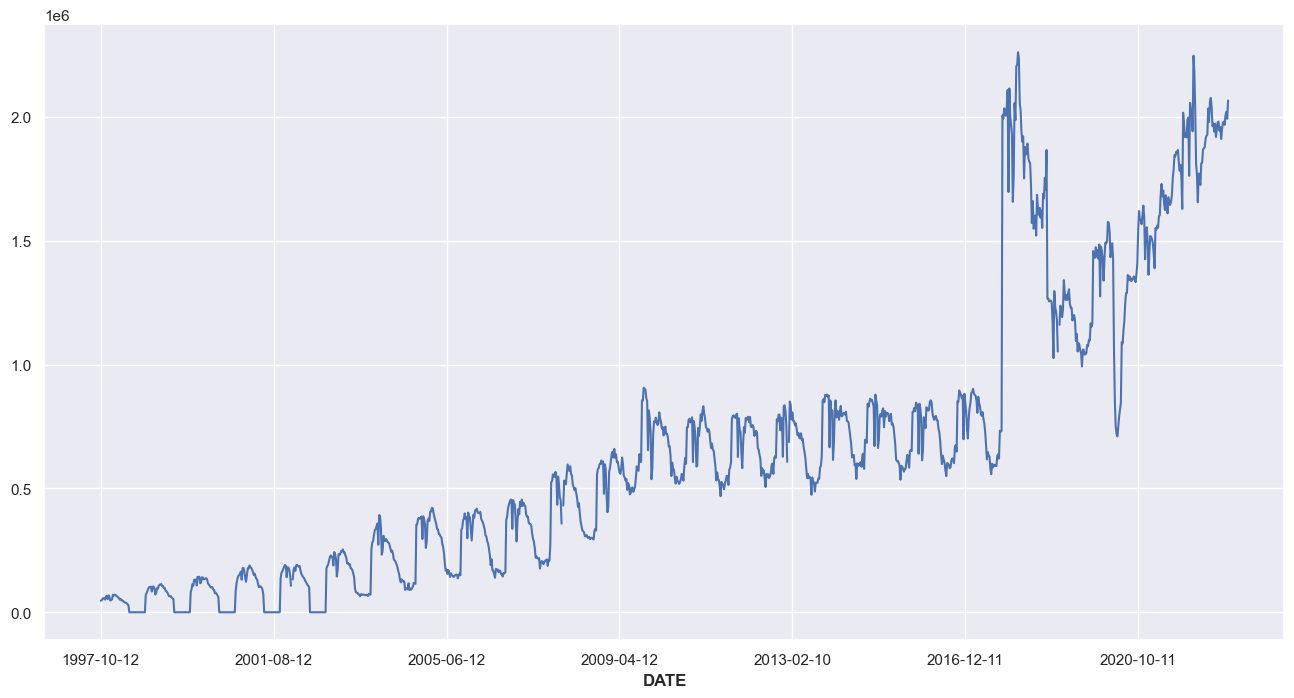

In [98]:
figsize = (16, 8)
dataset.set_index(time_col)[target_col].plot(figsize=figsize);

<Axes: xlabel='DATE'>

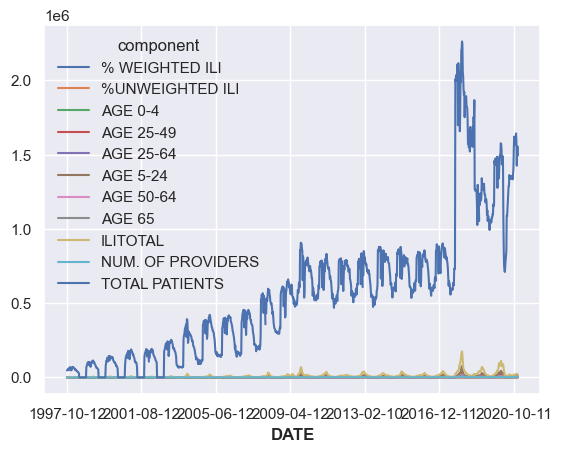

In [99]:
dataset[dataset.DATE < '2021'].set_index(time_col).plot()

<Axes: xlabel='DATE'>

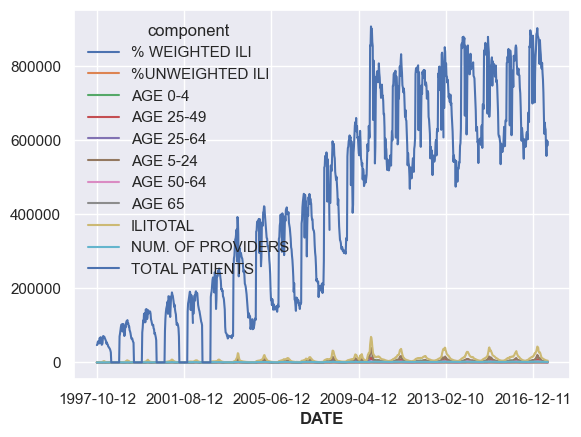

In [100]:
dataset[dataset.DATE < '2017-08'].set_index(time_col).plot()

In [101]:
# trim the anomaly part
dataset_partial = df_filled[df_filled.DATE < '2017-08']

In [102]:
dataset_partial

component,DATE,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS
0,1997-10-12,1.101480,1.216860,179.0,0.0,157.0,205.0,0.0,29.0,570.0,192.0,46842.0
1,1997-10-19,1.200070,1.280640,199.0,0.0,151.0,242.0,0.0,23.0,615.0,191.0,48023.0
2,1997-10-26,1.378760,1.239060,228.0,0.0,153.0,266.0,0.0,34.0,681.0,219.0,54961.0
3,1997-11-02,1.199200,1.144730,188.0,0.0,193.0,236.0,0.0,36.0,653.0,213.0,57044.0
4,1997-11-09,1.656180,1.261120,217.0,0.0,162.0,280.0,0.0,41.0,700.0,213.0,55506.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1029,2017-07-02,0.859531,0.961603,1771.0,1121.0,6090.0,1748.0,489.0,467.0,5596.0,1422.0,581945.0
1030,2017-07-09,0.818998,0.955818,1728.0,1111.0,6090.0,1564.0,505.0,418.0,5326.0,1456.0,557219.0
1031,2017-07-16,0.752505,0.827597,1545.0,1004.0,6090.0,1578.0,462.0,372.0,4961.0,1405.0,599446.0
1032,2017-07-23,0.731146,0.811886,1549.0,908.0,6090.0,1421.0,450.0,419.0,4747.0,1384.0,584688.0


In [103]:
dataset_partial['DATE'] = dataset_partial['DATE'].astype('str')

C:\Users\saira\AppData\Local\Temp\ipykernel_21328\1473158665.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_partial['DATE'] = dataset_partial['DATE'].astype('str')


In [104]:
# dataset[target_col] = dataset[target_col].astype(float)

In [105]:
# dataset.head()

Split dataset into train and test sets

In [106]:
train_size = 0.9
train_points = int(train_size*len(dataset_partial))
train_df = dataset_partial.iloc[:train_points]
test_df = dataset_partial.iloc[train_points:]

Plot graph

In [107]:
train_df['DATE'] = train_df['DATE'].astype('str')

C:\Users\saira\AppData\Local\Temp\ipykernel_21328\1870464413.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['DATE'] = train_df['DATE'].astype('str')


### **Train API**

Train data: convert df to list-of-list

In [108]:
train_data = []
for value in train_df.values:
    train_data.append(list(value))

In [109]:
train_data[:2]

[['1997-10-12',
  1.10148,
  1.21686,
  179.0,
  0.0,
  157.0,
  205.0,
  0.0,
  29.0,
  570.0,
  192.0,
  46842.0],
 ['1997-10-19',
  1.20007,
  1.28064,
  199.0,
  0.0,
  151.0,
  242.0,
  0.0,
  23.0,
  615.0,
  191.0,
  48023.0]]

Custom Model Request (optional)

In [110]:
# Default model request
model_request = {
    'type': 'meta_wa',
    'scorers': ['smape', 'mase'],
    'params': {
        'preprocessors': [
            {'type': 'dartsimputer'},
            {'type': 'minmaxscaler'},
        ],
        'base_models': [
            # {'type': 'darts_naive'},
            {'type': 'darts_seasonalnaive'},
            # {'type': 'darts_autotheta'},
            # {'type': 'darts_autoarima'},
            # {'type': 'darts_autoets'},
        ],
    },
}

# # Onboard NeuralProphet customized model request
# np_external_model_request = {
#     'params': {
#       'changepoints_range': 0.2,
#       'epochs': 2,
#       'growth': 'off'
#     },
#     'metrics': [],
#     'type': 'neuralprophet',
# }
# # np_external_model_request = None

user_value = 0.7
output_type = 'estimate'  # 'data', 'estimate'
mauq_external_params = {
    'problem_type': 'regression',
    'confidence_level': user_value,
    'output_type': output_type

}

deepsybil_external_model_request = {
    'type': 'meta_wa',  # 'meta_naive', 'meta_wa'
    'scorers': ['mase', 'smape'],
    'params': {
        'preprocessors': [
            # {'type': 'dartsimputer'},
            # {'type': 'simpleimputer', 'params': {'strategy': 'mean'}},
            {'type': 'minmaxscaler'},
        ],
        'base_models': [
            # {'type': 'darts_rnn',
            #  'params': {
            #      'model': 'LSTM',
            #      'hidden_dim': 10,
            #      'n_rnn_layers': 3
            # }},
            # {'type': 'darts_tcn',
            #  'params': {
            #      'output_chunk_length': 52,
            #      'input_chunk_length': 104,                 
            #      'n_epochs': 20,
            # }},
            # {'type': 'darts_rnn',
            #  'params': {
            #      'model': 'LSTM',
            #      'hidden_dim': 10,
            #      'n_rnn_layers': 3
            # }},
            # {'type': 'darts_nlinear'},
            # {'type': 'darts_dlinear'},
            # {'type': 'darts_blockrnn'},
            {'type': 'darts_tsmixer',
             'params': {
                 'output_chunk_length': 52,
                 'input_chunk_length': 104,                 
                 'n_epochs': 20,
            }},
            #  {'type': 'darts_tide'}
        ],
    },
}


# # Customized model request
model_request = {
    'type': 'meta_wa',  # 'meta_naive', 'meta_wa'
    'scorers': ['mase', 'smape'],
    'params': {
        'preprocessors': [
            # {'type': 'dartsimputer'},
            # {'type': 'simpleimputer', 'params': {'strategy': 'mean'}},
            # {'type': 'minmaxscaler'},
        ],
        'base_models': [
            # {'type': 'darts_naive'},
            # {'type': 'darts_seasonalnaive'},
            # {'type': 'darts_autotheta'},
            # {'type': 'stats_autotheta'},
            # {'type': 'darts_autoets'},
            # {'type': 'stats_autoets'},
            # {'type': 'darts_autoarima'},
            # {'type': 'stats_autoarima'},
            # {'type': 'darts_autoces'},
            # {'type': 'darts_kalman'},
            # {'type': 'darts_catboost'},            
            # # {'type': 'darts_tbats'},
            # # {'type': 'darts_linearregression'},
            # {'type': 'darts_lightgbm',
            #  'params': {
            #      'lags': 12,
            #      'output_chunk_length': 6,
            #      'verbose': -1
            # }}
            # {'type': 'neuralprophet',
            #  'external_params': np_external_model_request
            # }  # Onboard NeuralProphet external service
            {'type': 'deepsybil',
             'external_params': deepsybil_external_model_request
            }  # Onboard NeuralProphet external service
        ],
        
    },
    'mauq_params':mauq_external_params,
}

This is for JSON model_request

In [111]:
# file_path = 'model_request.json'
# # For writing the model request to a json file
# with open(file_path, 'r') as file:
#     model_request = json.load(file)

This is for YAML model_request

In [112]:
# file_path = 'model_request.yaml'
# # For reading the model request from a yaml file
# with open(file_path, 'r') as file:
#     model_request = yaml.safe_load(file)

Train API JSON Payload

In [113]:
api_json = {
    'data': train_data,
    'model': model_request  # (optional) can be commented out
}

Build URL

In [114]:
with open('url.yaml', 'r') as file:
    url_dict = yaml.safe_load(file)

In [115]:
# URL to our SYBIL AWS service
protocol = url_dict['protocol']
host = url_dict['host']
port = url_dict['port']
endpoint = 'train'

url = '%s://%s:%s/%s' % (protocol, host, str(port), endpoint)

In [116]:
# protocol, host, port

Call endpoint, receive response JSON, write to output file

In [117]:
%%time
response = requests.post(url, json=api_json)
print(response)
print()

<Response [200]>

CPU times: total: 0 ns
Wall time: 5min 9s


In [118]:
train_json_out = response.json()  # dict output
train_json_out

{'model': '...',
 'type': 'meta_wa',
 'metrics': [{'type': 'mase', 'value': 2.7922321063229325},
  {'type': 'smape', 'value': 8.808519945728756}],
 'estimate': 77072.22818185693}

### **Forecast API**

Forecast Dates: predict the next 32 years of temperature anomaly data (1980-2012)

In [119]:
test_data = []
for value in test_df.drop(columns=target_col).values:
    test_data.append(list(value))

In [120]:
test_data[:2]

[['2015-08-09',
  0.743224,
  0.821165,
  1392.0,
  1026.0,
  6090.0,
  1590.0,
  420.0,
  325.0,
  4753.0,
  1364.0],
 ['2015-08-16',
  0.805251,
  0.819435,
  1330.0,
  1062.0,
  6090.0,
  1667.0,
  400.0,
  291.0,
  4750.0,
  1340.0]]

Model from Train API

In [121]:
model = train_json_out['model']
estimate=train_json_out['estimate']

Forecast API JSON Payload

In [122]:
api_json = {
    'model': model,
    'data': test_data,
    'estimate':estimate
}

Build URL (same as train except for the endpoint)

In [123]:
endpoint = 'forecast'

url = '%s://%s:%s/%s' % (protocol, host, str(port), endpoint)

Call endpoint, receive response JSON, write to output file

In [124]:
%%time
response = requests.post(url, json=api_json)
print(response)
print()

<Response [200]>

CPU times: total: 15.6 ms
Wall time: 2.84 s


In [125]:
forecast_json_out = response.json()  # dict output
forecast_json_out

{'data': [['2015-08-09',
   537287.5980825761,
   460215.36990071915,
   614359.826264433],
  ['2015-08-16', 594965.5429962218, 517893.3148143649, 672037.7711780787],
  ['2015-08-23', 556077.6081889372, 479005.38000708027, 633149.8363707941],
  ['2015-08-30', 551377.8632971604, 474305.63511530345, 628450.0914790173],
  ['2015-09-06', 560741.5629428023, 483669.3347609454, 637813.7911246592],
  ['2015-09-13', 600504.8105437937, 523432.5823619368, 677577.0387256506],
  ['2015-09-20', 674307.3604796402, 597235.1322977833, 751379.5886614971],
  ['2015-09-27', 665708.5203649987, 588636.2921831418, 742780.7485468556],
  ['2015-10-04', 695683.5002332937, 618611.2720514368, 772755.7284151507],
  ['2015-10-11', 755651.2609731329, 678579.032791276, 832723.4891549898],
  ['2015-10-18', 799695.1601921724, 722622.9320103155, 876767.3883740293],
  ['2015-10-25', 824970.9192351187, 747898.6910532617, 902043.1474169756],
  ['2015-11-01', 864022.4285035137, 786950.2003216568, 941094.6566853706],
  ['201

Combine forecast dates and output

In [126]:
forecast_df = pd.DataFrame(
    data=forecast_json_out['data'],
    columns=[time_col, target_col,"lower_interval","upper_interval"],
)

In [127]:
forecast_df.shape

(104, 4)

In [128]:
forecast_df.columns

Index(['DATE', 'TOTAL PATIENTS', 'lower_interval', 'upper_interval'], dtype='object')

In [129]:
forecast_df.head()

,DATE,TOTAL PATIENTS,lower_interval,upper_interval
0,2015-08-09,537287.598083,460215.369901,614359.826264
1,2015-08-16,594965.542996,517893.314814,672037.771178
2,2015-08-23,556077.608189,479005.380007,633149.836371
3,2015-08-30,551377.863297,474305.635115,628450.091479
4,2015-09-06,560741.562943,483669.334761,637813.791125


In [130]:
forecast_df.tail()

,DATE,TOTAL PATIENTS,lower_interval,upper_interval
99,2017-07-02,545487.343757,468415.115575,622559.571939
100,2017-07-09,577008.755636,499936.527454,654080.983818
101,2017-07-16,534491.230637,457419.002455,611563.458819
102,2017-07-23,525733.165957,448660.937776,602805.394139
103,2017-07-30,537113.899884,460041.671702,614186.128066


Plot train and forecast side-by-side

C:\Users\saira\AppData\Local\Temp\ipykernel_21328\2998340865.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['color'] = 'b'


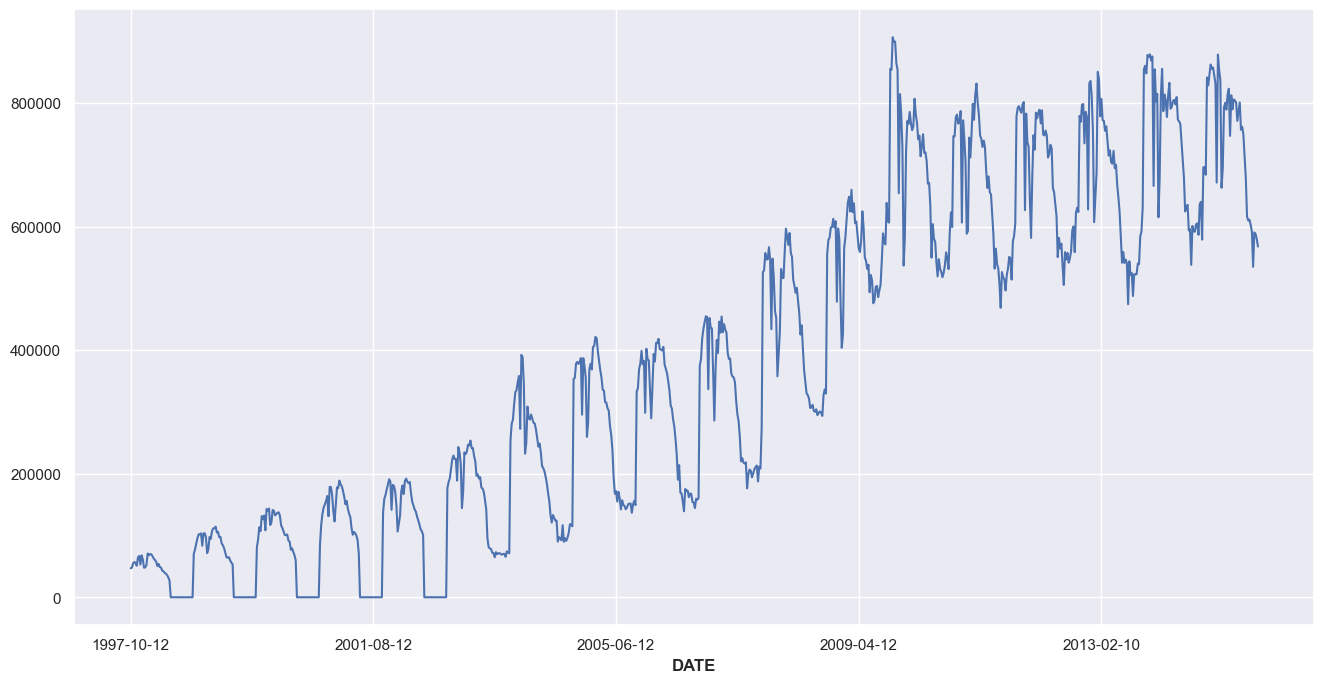

In [131]:
train_df['color'] = 'b'
train_df.set_index(time_col)[target_col].plot(figsize=figsize, color=train_df['color']);

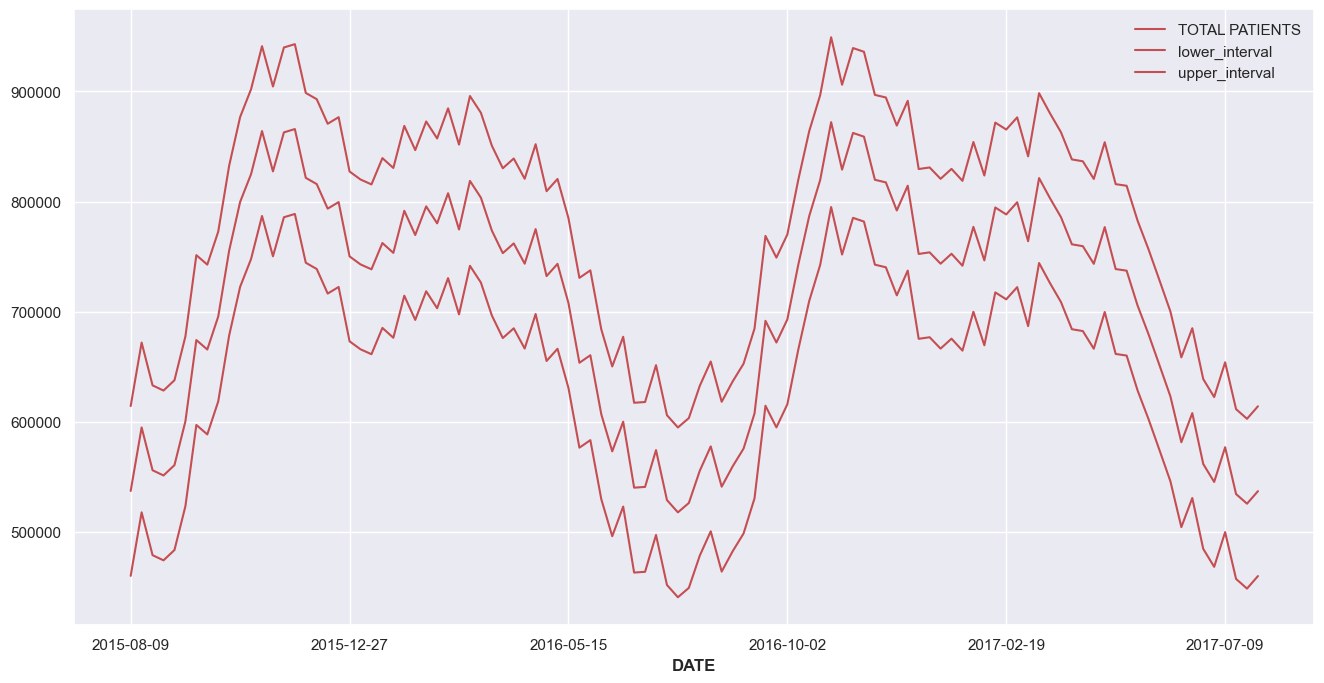

In [132]:
forecast_df['color'] = 'r'
forecast_df.set_index(time_col).plot(figsize=figsize, color=forecast_df['color']);

Combine train and forecast sets

In [133]:
df = pd.concat([train_df, forecast_df]).reset_index(drop=True)

In [134]:
df.shape

(1034, 15)

In [135]:
df.head()

,DATE,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,color,lower_interval,upper_interval
0,1997-10-12,1.10148,1.21686,179.0,0.0,157.0,205.0,0.0,29.0,570.0,192.0,46842.0,b,NaN,NaN
1,1997-10-19,1.20007,1.28064,199.0,0.0,151.0,242.0,0.0,23.0,615.0,191.0,48023.0,b,NaN,NaN
2,1997-10-26,1.37876,1.23906,228.0,0.0,153.0,266.0,0.0,34.0,681.0,219.0,54961.0,b,NaN,NaN
3,1997-11-02,1.19920,1.14473,188.0,0.0,193.0,236.0,0.0,36.0,653.0,213.0,57044.0,b,NaN,NaN
4,1997-11-09,1.65618,1.26112,217.0,0.0,162.0,280.0,0.0,41.0,700.0,213.0,55506.0,b,NaN,NaN


In [136]:
df.tail()

,DATE,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,color,lower_interval,upper_interval
1029,2017-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,545487.343757,r,468415.115575,622559.571939
1030,2017-07-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,577008.755636,r,499936.527454,654080.983818
1031,2017-07-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,534491.230637,r,457419.002455,611563.458819
1032,2017-07-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,525733.165957,r,448660.937776,602805.394139
1033,2017-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,537113.899884,r,460041.671702,614186.128066


Plot combined train and forecast sets with the vertical black line as the cut-off

Plot original dataset to compare

Plot original dataset (blue) with SYBIL forecasted values (red)

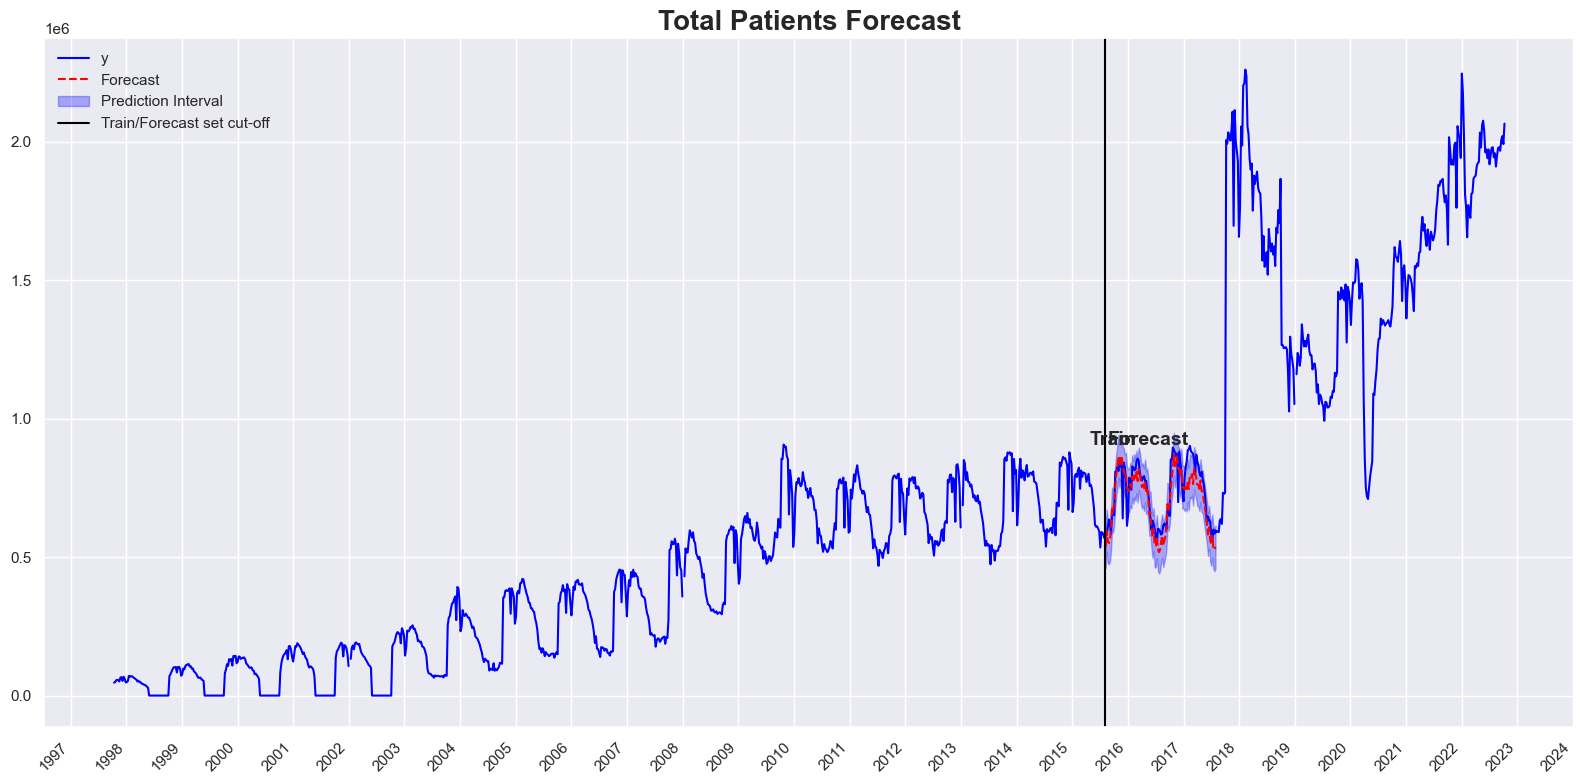

In [137]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd  # Import pandas if you haven't already

# Ensure time_col is datetime
df[time_col] = pd.to_datetime(df[time_col])
forecast_df[time_col] = pd.to_datetime(forecast_df[time_col])

plt.figure(figsize=figsize)

dataset['DATE'] = pd.to_datetime(dataset['DATE'], format='%Y-%m') # Corrected line

plt.plot(dataset[time_col], dataset[target_col], color='blue', label='y')
# plt.plot(df[time_col], df[target_col], color='blue', label='y')

plt.plot(forecast_df[time_col], forecast_df[target_col], color='red', linestyle='dashed', label='Forecast')

plt.fill_between(forecast_df[time_col], forecast_df['lower_interval'], forecast_df['upper_interval'],
                 color='blue', alpha=0.3, label='Prediction Interval')

plt.axvline(x=df[time_col].iloc[len(train_df)-1], color='black', label='Train/Forecast set cut-off')

plt.text(df[time_col].iloc[len(train_df)-15], df[target_col].max(), 'Train', fontweight='bold', fontsize=14)
plt.text(df[time_col].iloc[len(train_df)+2], df[target_col].max(), 'Forecast', fontweight='bold', fontsize=14)

# Format x-axis to show years clearly
ax = plt.gca()

# Display a tick every year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Adjust label rotation and alignment
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.title('Total Patients Forecast', fontweight='bold', fontsize=20)
plt.legend()
plt.tight_layout()
plt.show()
